### Get Data Loader

In [1]:
import os
import torch
import numpy as np
import random
from datetime import datetime
from tqdm import tqdm  

# --- Project-specific imports ---
import config_potamogaton as cfg
import cnn_utils.data as data_utils

torch.manual_seed(cfg.random_seed)
np.random.seed(cfg.random_seed)
random.seed(cfg.random_seed)

print("Imports complete. Ready to set up the training run.\n")

train_dataloader, val_dataloader, test_dataloader = data_utils.get_3_dataloaders(cfg)
val_ood_dataloader, test_ood_dataloader = None, None

cfg.apply_matplotlib_styles()

def save_pdf_fig(fig, filename):
    
    if not filename.endswith('.pdf'):
        filename += '.pdf'
    
    save_path = os.path.join(cfg.FIGURE_SAVE_DIR, filename)
    os.makedirs(cfg.FIGURE_SAVE_DIR, exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight')

/home/takayuki/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Imports complete. Ready to set up the training run.

 Total dataset size 	: 105
 Train dataset size 	: 83
 Val dataset size 	: 11
 Test dataset size 	: 11

Global Matplotlib styles applied.


### Load model file

In [5]:
import config_potamogaton as cfg
from cnn_utils.model import load_model

MODEL_PATH = cfg.best_model_path
print(f"Loading model from: {MODEL_PATH}")
model = load_model(MODEL_PATH)

Loading model from: /home/takayuki/Desktop/summer2025/plants/training/potamogaton/models/best_loss_model_09-05_17-25--58_a1_potamogaton_convnextv2_tiny.fcmae_ft_in22k_in1k.pth
Model loaded successfully from /home/takayuki/Desktop/summer2025/plants/training/potamogaton/models/best_loss_model_09-05_17-25--58_a1_potamogaton_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


## Evaluation

In [6]:
from cnn_utils.evaluate import EvalClassification

test_eval = EvalClassification(cfg, model, test_dataloader)
test_eval.evaluate_accuracy()

  -- Evaluating: 100%|██████████| 11/11 [00:01<00:00,  7.02it/s]


Accuracy: 1.0000


1.0

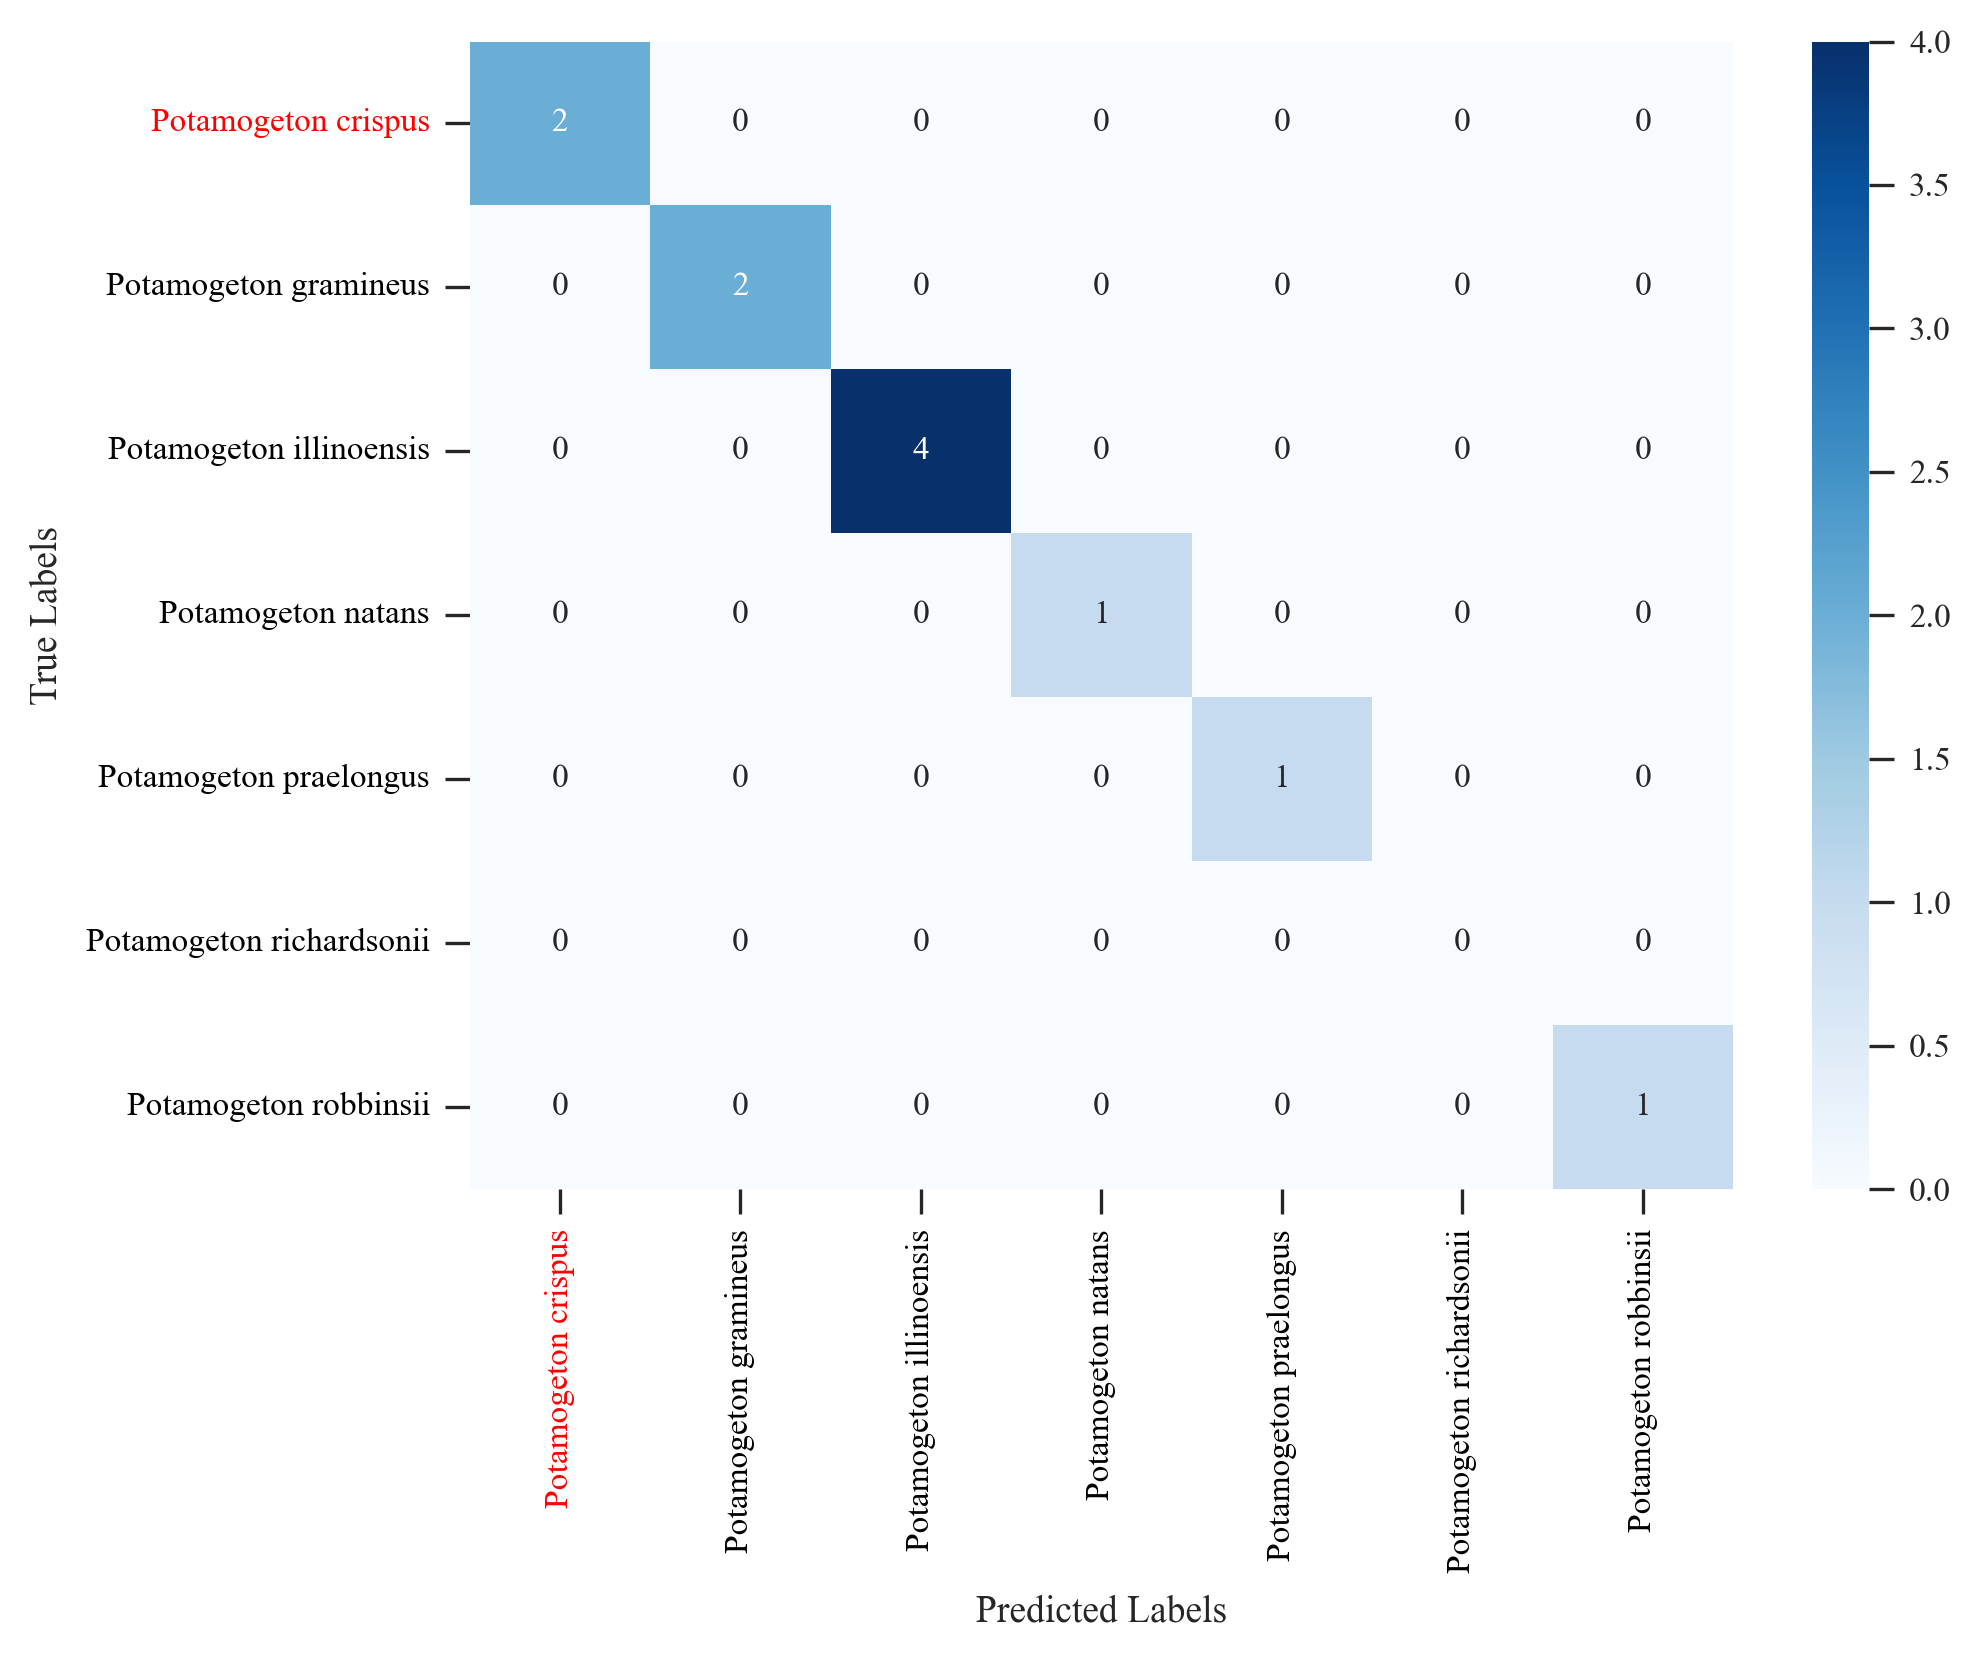


Per-Class Metrics:
+--------------------------+-----------+------+------+------+-------------+----------------+-------+------------+---------------------+-------+
| Class                    |   Support |   TP |   FN |   FP |   Precision |   Recall (TPR) |   FNR |   F1-Score |   Specificity (TNR) |   FPR |
+==========================+===========+======+======+======+=============+================+=======+============+=====================+=======+
| Potamogeton crispus      |         2 |    2 |    0 |    0 |           1 |              1 |     0 |          1 |                   1 |     0 |
+--------------------------+-----------+------+------+------+-------------+----------------+-------+------------+---------------------+-------+
| Potamogeton gramineus    |         2 |    2 |    0 |    0 |           1 |              1 |     0 |          1 |                   1 |     0 |
+--------------------------+-----------+------+------+------+-------------+----------------+-------+------------+---

In [7]:
_, fig = test_eval.get_classwise_confusion_matrix(return_fig=True)
summary_metrics = test_eval.get_classwise_metrics()
# save_pdf_fig(fig, 'test_classwise_cm')

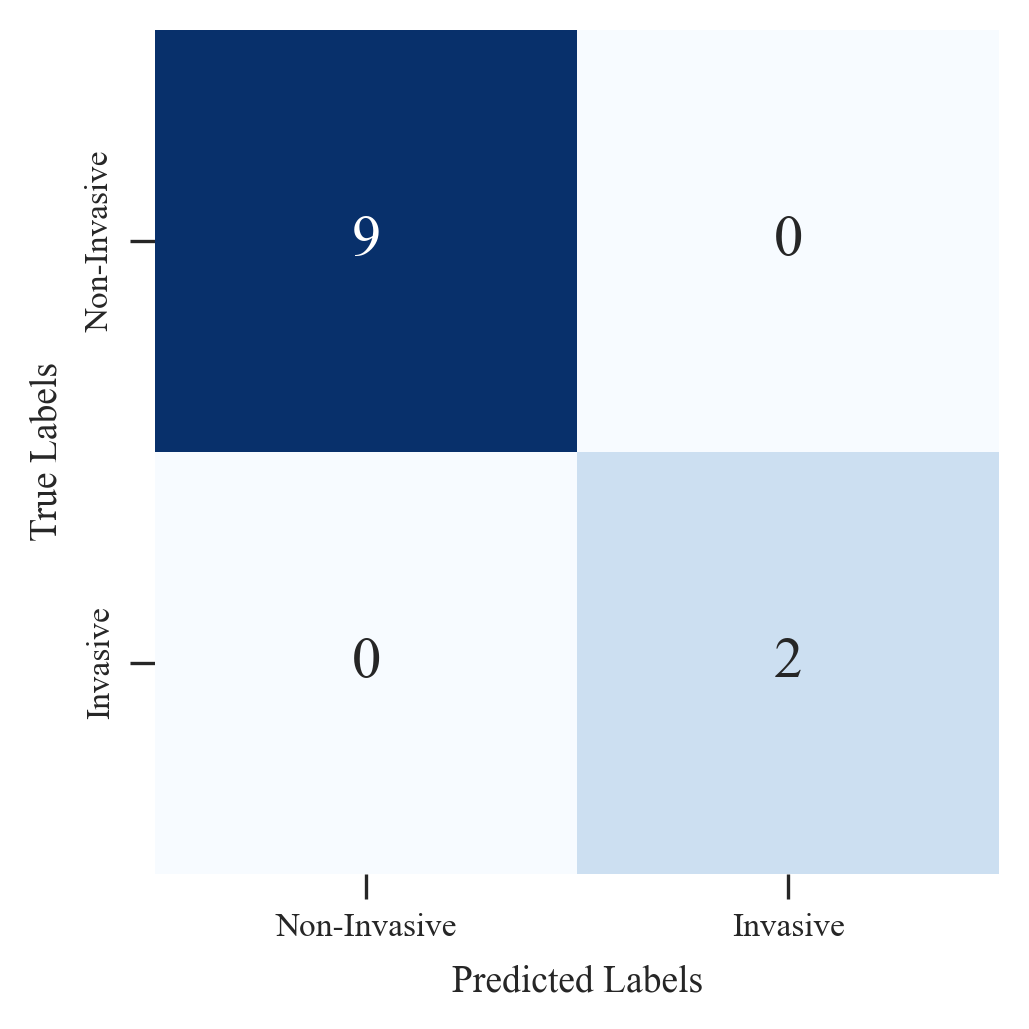


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        2 | False Positive Rate (FPR)      |         0 | Negative Predictive Value (NPV) |         1 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |        9 | False Negative Rate (FNR)      |         0 | Positive " (PPV or Precision)   |         1 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        0

In [8]:
_, fig = test_eval.get_binary_confusion_matrix(return_fig=True)
binary_matrics = test_eval.get_binary_metrics()
# save_pdf_fig(fig, 'test_binary_cm')

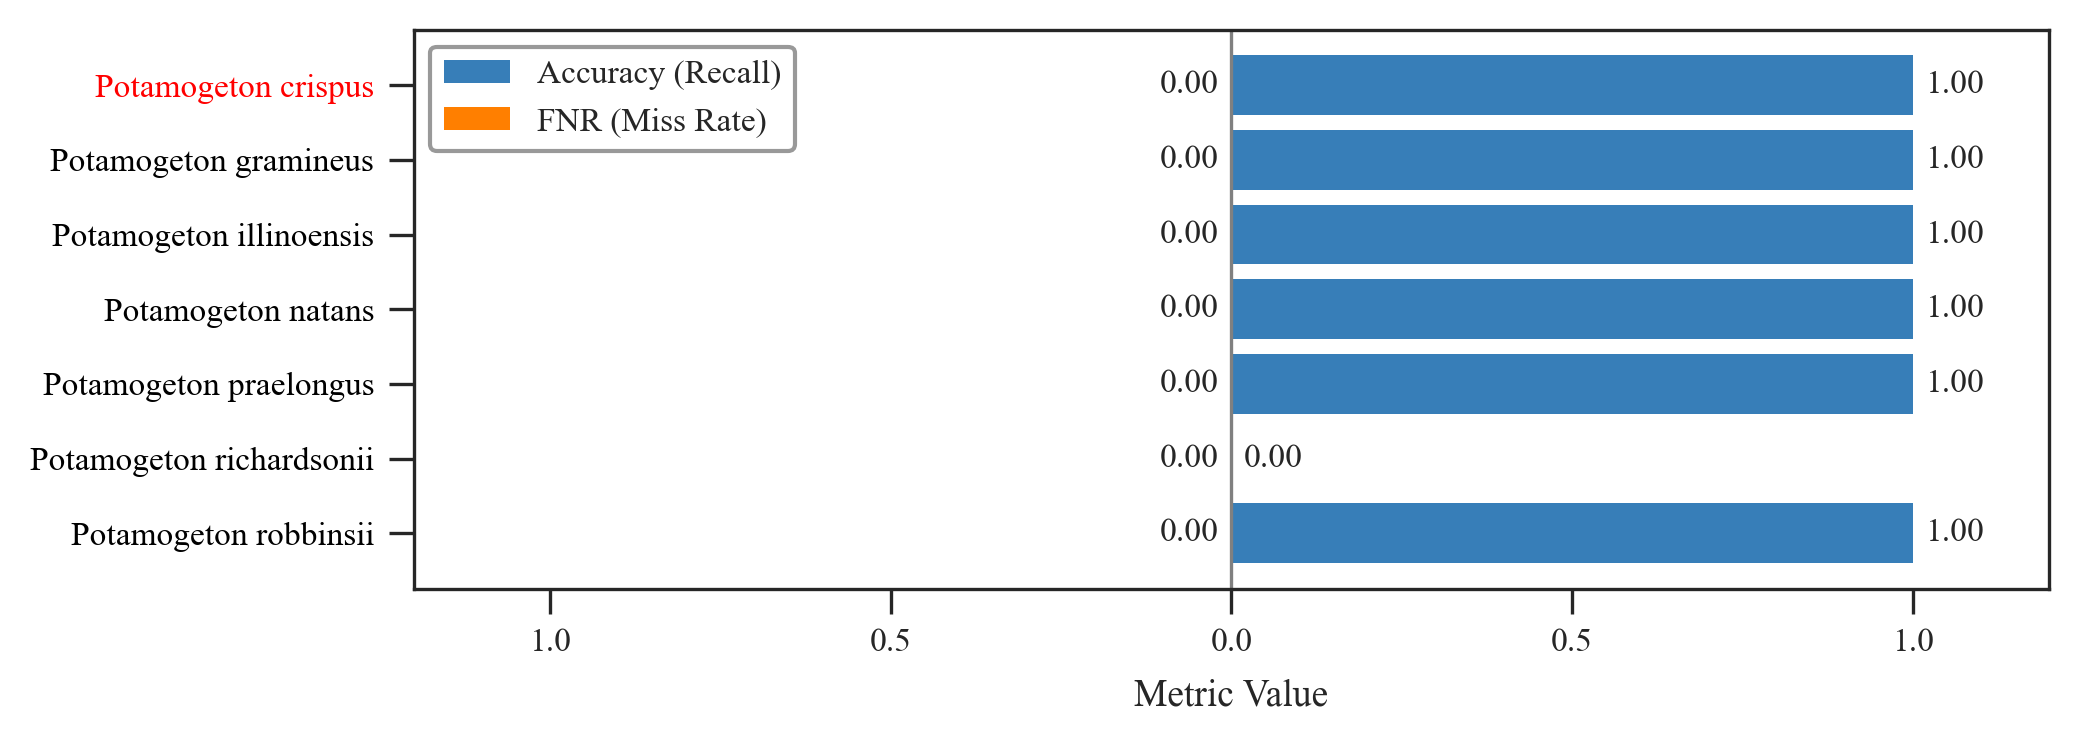

In [9]:
fig = test_eval.visualize_classwise_metrics(return_fig=True)
# save_pdf_fig(fig, 'test_classwise_metrics')

## Full dataset

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/potamogaton
Found 7 classes locally: ['Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton natans', 'Potamogeton praelongus', 'Potamogeton richardsonii', 'Potamogeton robbinsii']
Remapped 105 images to use canonical indices.
Total dataset size 	: 105
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 105

Test DataLoader created with 105 images from /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/potamogaton.


  -- Evaluating:   0%|          | 0/105 [00:00<?, ?it/s]

  -- Evaluating: 100%|██████████| 105/105 [00:13<00:00,  7.97it/s]


Accuracy: 0.9619


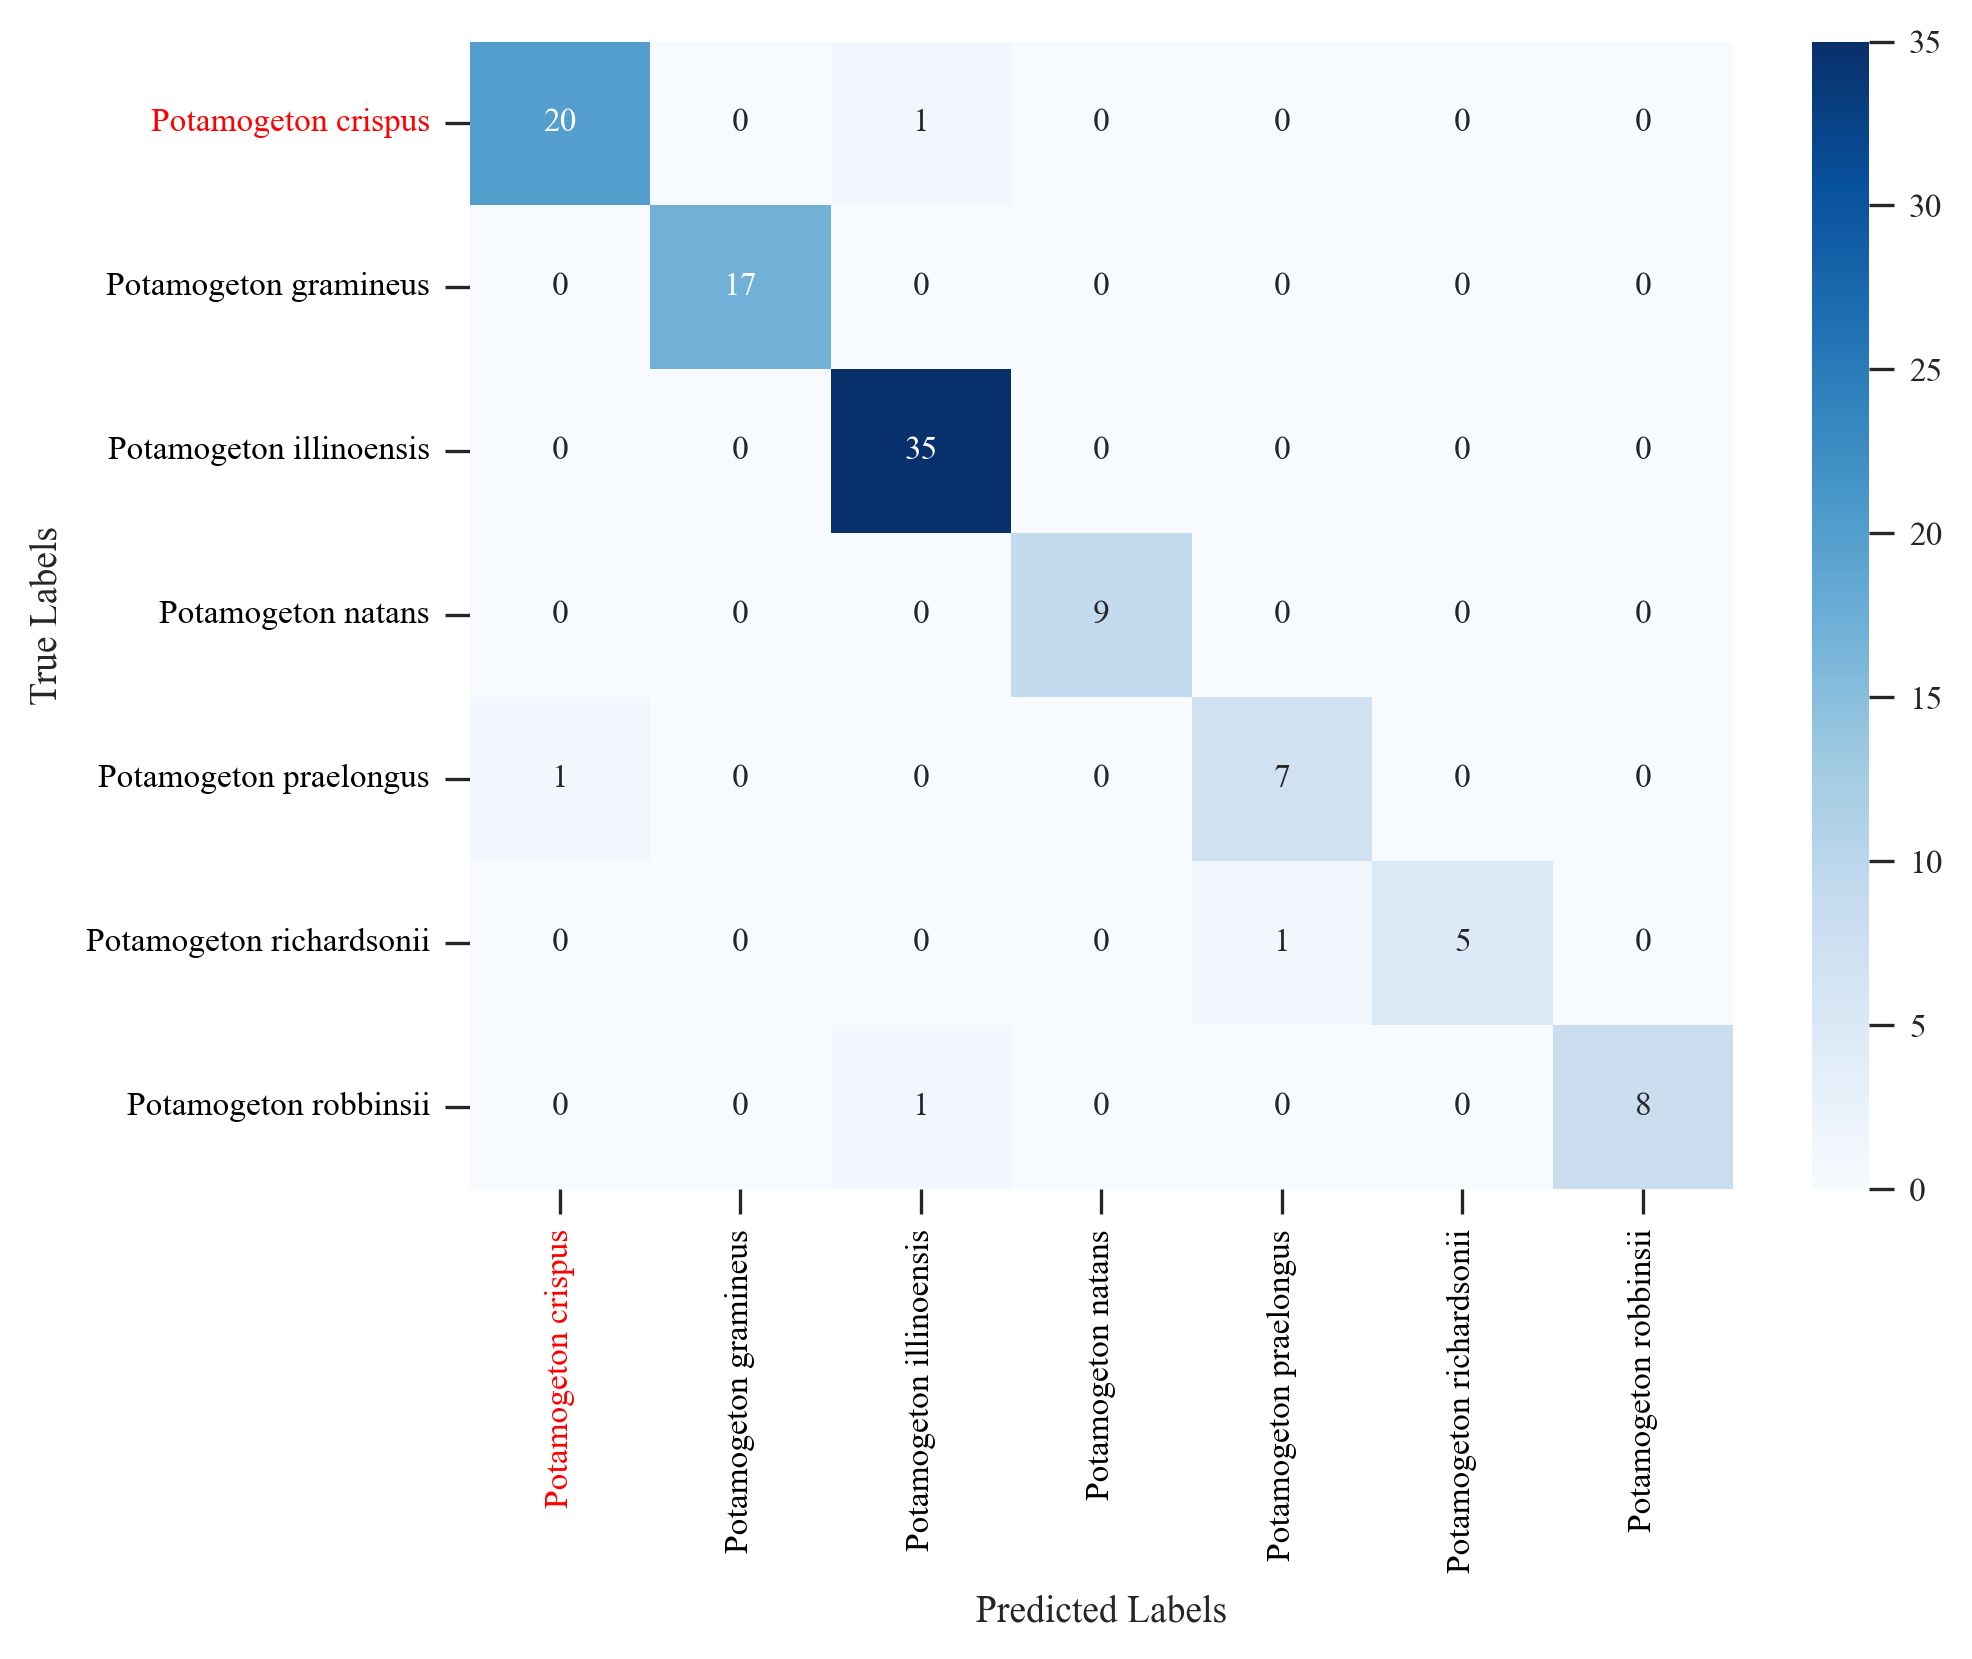

In [10]:
full_dataloader = data_utils.get_single_dataloader(cfg, cfg.main_data_dir)
full_eval = EvalClassification(cfg, model, full_dataloader)
full_eval.evaluate_accuracy()
_, fig = full_eval.get_classwise_confusion_matrix(return_fig=True)
# save_pdf_fig(fig, 'full_classwise_cm')